In [1]:
%pip install torch torchvision torchaudio

  Using cached torchvision-0.25.0-cp311-cp311-macosx_11_0_arm64.whl.metadata (5.4 kB)
Using cached torchvision-0.25.0-cp311-cp311-macosx_11_0_arm64.whl (1.9 MB)
Note: you may need to restart the kernel to use updated packages.


In [2]:
%pip install opencv-python

Note: you may need to restart the kernel to use updated packages.


In [1]:
from torchvision.transforms import v2

def get_transforms(train=False, size=(512, 512)):
    t = []
    # 1. Resize both Image and Mask to a standard size
    # We use InterpolationMode.NEAREST for masks automatically in v2
    t.append(v2.Resize(size))
    
    # 2. Convert to Tensor and Rescale
    t.append(v2.ToImage())
    t.append(v2.ToDtype(torch.float32, scale=True))
    
    if train:
        # Augmentations for Training ONLY
        t.append(v2.RandomHorizontalFlip(p=0.5))
        t.append(v2.RandomVerticalFlip(p=0.5))
        t.append(v2.RandomRotation(degrees=15))
        t.append(v2.ColorJitter(brightness=0.2, contrast=0.2))
    
    return v2.Compose(t)

In [2]:
import os
import numpy as np
from PIL import Image
from torch.utils.data import Dataset
from torchvision import tv_tensors

class KvasirDataset(Dataset):
    def __init__(self, root, transforms=None):
        self.root = root
        self.transforms = transforms
        self.imgs = sorted(os.listdir(os.path.join(root,"images")))
        self.masks = sorted(os.listdir(os.path.join(root,"masks")))

    def __getitem__(self,idx):
        img_path = os.path.join(self.root,"images",self.imgs[idx])
        mask_path = os.path.join(self.root, "masks", self.masks[idx])
        #Load as PIL
        img = Image.open(img_path).convert("RGB")
        mask = Image.open(mask_path).convert("L")
        #Wrap in torchvision v2 tensors for automatic coordinate resizing
        img = tv_tensors.Image(img)
        mask = tv_tensors.Mask(mask)
        if self.transforms is not None:
            img,mask=self.transforms(img, mask)
        #Generate binary masks for the polyp(value 1)
        #Masks are now scaled to the standard size(e.g., 512x512)
        binary_mask = (mask>0.5).to(torch.uint8)
        obj_ids = torch.unique(binary_mask)
        obj_ids = obj_ids[obj_ids > 0] #Remove background 
        masks = (binary_mask == obj_ids[:, None, None]).to(torch.uint8)
        #Calculate bounding boxes from the resized masks
        num_objs = len(obj_ids)
        boxes = []
        for i in range(num_objs):
            pos = torch.where(masks[i])
            xmin, xmax = torch.min(pos[1]),torch.max(pos[1])
            ymin, ymax = torch.min(pos[0]), torch.max(pos[0])
            boxes.append([xmin, ymin, xmax, ymax])
        target = {
            "boxes": torch.as_tensor(boxes,dtype=torch.float32),
            "labels": torch.ones((num_objs,),dtype=torch.int64),
            "masks": masks,
            "image_id": torch.tensor([idx])
        }
        return img, target

    def __len__(self):
        return len(self.imgs)

In [3]:
import torch
from torch.utils.data import Subset, ConcatDataset, DataLoader, random_split
from torchvision import transforms as T

# 1. Initialize the full dataset
full_dataset = KvasirDataset(root='/Users/Meghana/Desktop/MS/Final Thesis Code/Kvasir-SEG')
#print(type(full_dataset))
# 2. Define split sizes (80% train, 20% test)
indices = torch.randperm(len(full_dataset)).tolist()
train_idx = indices[:int(0.8*len(indices))]
test_idx = indices[int(0.8*len(indices)):]

# 3. Perform the split
test_dataset = Subset(full_dataset, test_idx)
test_dataset.dataset.transforms = get_transforms(train=False)

train_orig = Subset(full_dataset, train_idx)
train_orig.dataset.transforms = get_transforms(train=False)

train_aug = Subset(full_dataset, train_idx)
train_aug.dataset.transforms = get_transforms(train=True)

train_dataset_final = ConcatDataset([train_orig, train_aug])

print(f"Training samples after augmentation : {len(train_dataset_final)}")
print(f"Testing samples: {len(test_dataset)}")
print(f"Original training data set:{len(train_idx)}")

Training samples after augmentation : 1600
Testing samples: 200
Original training data set:800


--- Dataset Properties ---
Total Train Samples: 1600
Total Test Samples:  200
Image Shape: torch.Size([3, 512, 512]) (C, H, W)
Number of Objects in first sample: 1
--------------------------



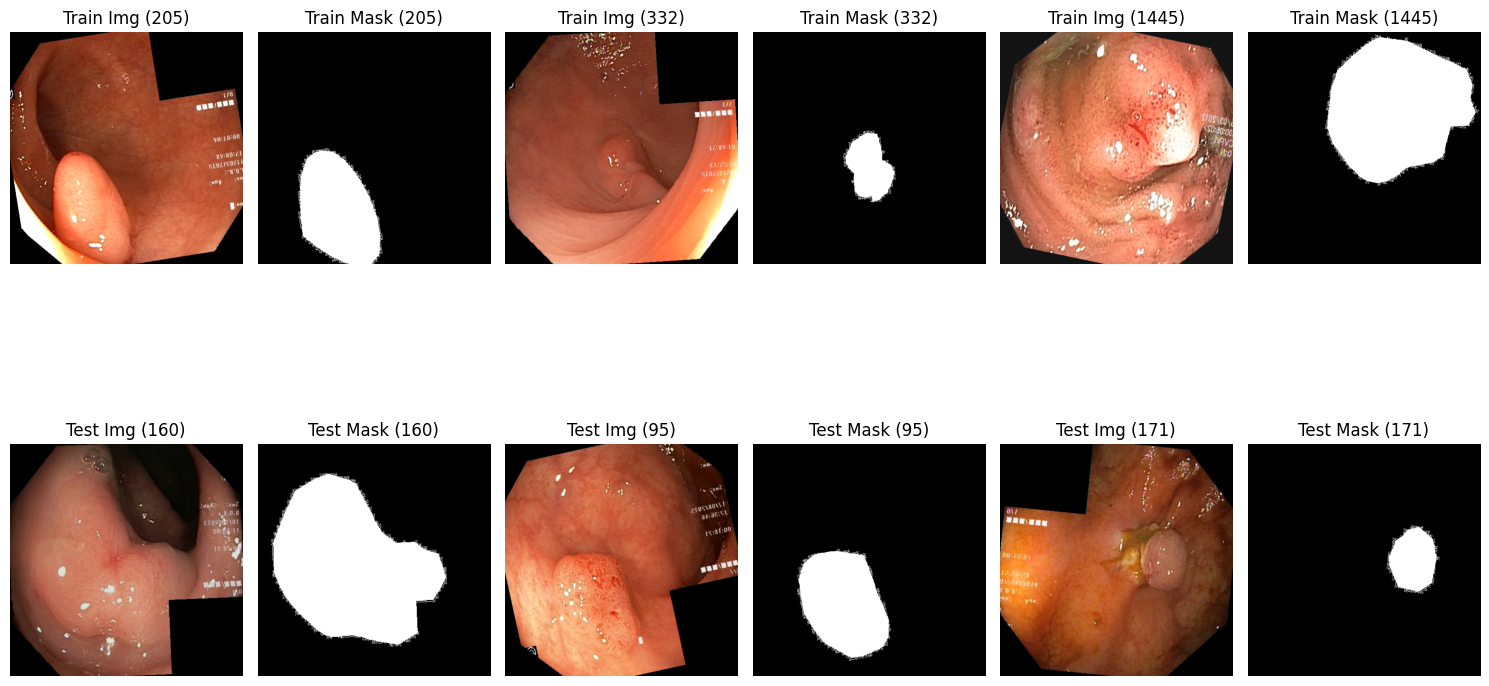

In [12]:
import matplotlib.pyplot as plt
import numpy as np
import torch

def visualize_splits(train_ds, test_ds, num_samples=3):
    # 1. Print Dataset Properties
    print("--- Dataset Properties ---")
    print(f"Total Train Samples: {len(train_ds)}")
    print(f"Total Test Samples:  {len(test_ds)}")
    
    # Get a sample to check dimensions
    sample_img, sample_target = train_ds[0]
    print(f"Image Shape: {sample_img.shape} (C, H, W)")
    print(f"Number of Objects in first sample: {len(sample_target['labels'])}")
    print("--------------------------\n")

    # 2. Setup Plot
    fig, axes = plt.subplots(2, num_samples * 2, figsize=(15, 10))
    
    # Helper to plot images
    def plot_subset(subset, row_idx, title_prefix):
        for i in range(num_samples):
            # Get a random image from the subset
            idx = torch.randint(0, len(subset), (1,)).item()
            img, target = subset[idx]
            
            # Convert tensor to numpy for plotting (C, H, W) -> (H, W, C)
            img_np = img.permute(1, 2, 0).numpy()
            
            # Extract and combine masks (if multiple instances exist)
            all_masks = target['masks'].cpu().numpy()
            combined_mask = np.max(all_masks, axis=0) if len(all_masks) > 0 else np.zeros_like(img_np[:,:,0])

            # Plotting
            ax_img = axes[row_idx, i*2]
            ax_img.imshow(img_np)
            ax_img.set_title(f"{title_prefix} Img ({idx})")
            ax_img.axis('off')

            ax_mask = axes[row_idx, i * 2 + 1]
            ax_mask.imshow(combined_mask, cmap='gray')
            ax_mask.set_title(f"{title_prefix} Mask ({idx})")
            ax_mask.axis('off')

    plot_subset(train_ds, 0, "Train")
    plot_subset(test_ds, 1, "Test")
    
    plt.tight_layout()
    plt.show()

# Execute visualization
visualize_splits(train_dataset_final, test_dataset)

In [ ]:
import cv2
import numpy as np
import torch
from tqdm import tqdm

def create_test_video(test_subset, video_name='kvasir_test_set.mp4',fps=5,size=(512,512)):
    fourcc = cv2.VideoWriter_fourcc(*'mp4v')
    video = cv2.VideoWriter(video_name, fourcc, fps, size)

    print(f"Generating video from {len(test_subset)} test samples...")

    for i in tqdm(range(len(test_subset))):
        #1.Get image from dataset
        img_tensor, _ = test_subset[i]
        #2.Convert PyTorch tensor to OpenCV format
        img_np = img_tensor.permute(1,2,0).cpu().numpy()
        img_np = (img_np*255).astype(np.uint8)
        #3.Convert RGB to BGR
        img_bgr = cv2.cvtColor(img_np, cv2.COLOR_RGB2BGR)
        #4.Ensure size matches VideoWriter exactly
        if (img_bgr.shape[1], img_bgr.shape[0]) !=size:
            img_bgr = cv2.resize(img_bgr, size)
        video.write(img_bgr)
    video.release()
    print(f"\nDone! Video saved as: {video_name}")

create_test_video(test_dataset, video_name="test_split_preview.mp4", fps=5)